Reading file 1: CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25)
File CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25): Shape (52010, 7)
Reading file 2: CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25)
File CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25): Shape (95495, 7)
Reading file 3: CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25)
File CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25): Shape (90056, 7)
Reading file 4: CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25)
File CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25): Shape (88186, 7)
Reading file 5: CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25)
File CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25): Shape (86377, 7)
Reading file 6: CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24)
File CAR - EP, Flow, Activity,

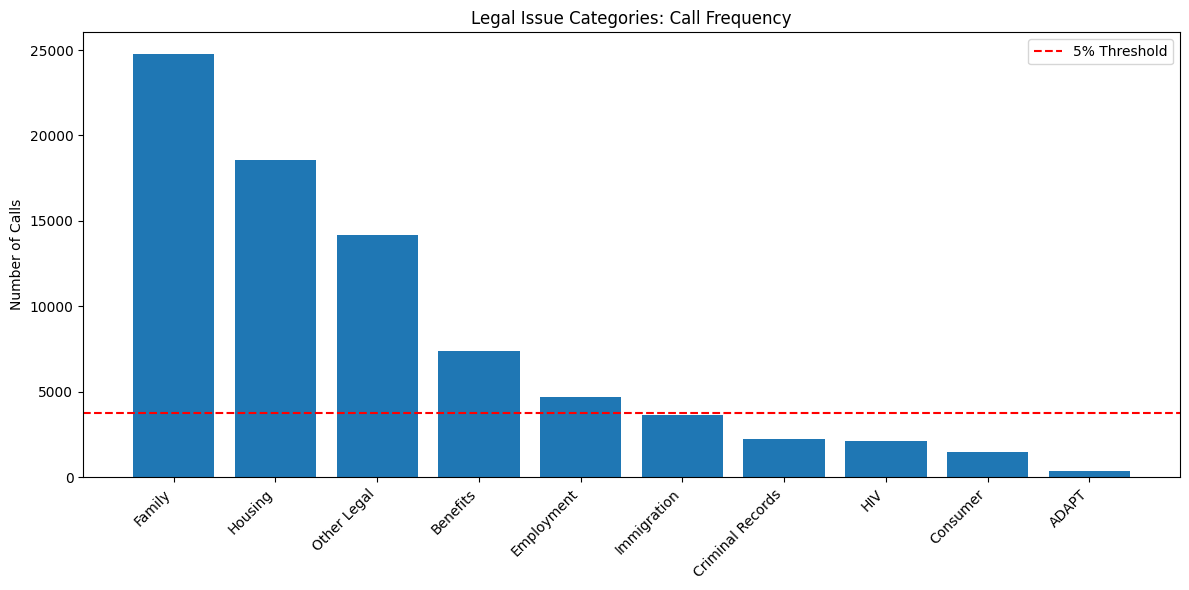


✓ Saved: viz2_monthly_comparison.png


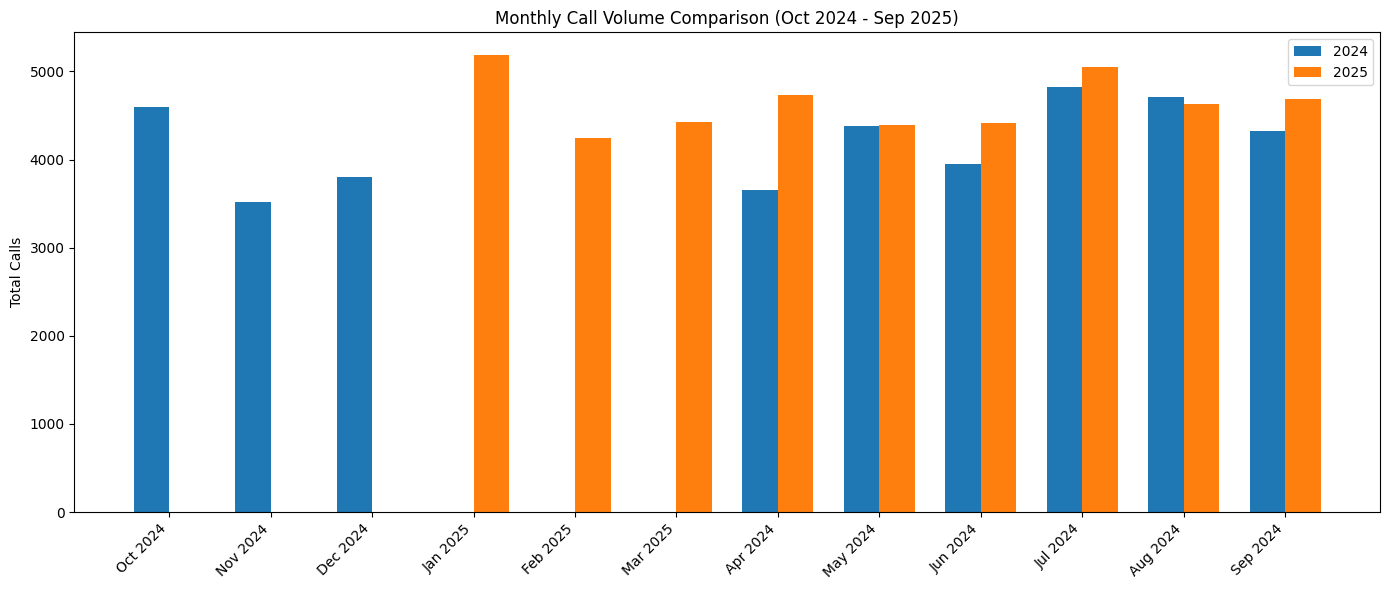


Total calls analyzed: 75,702
5% Threshold: 3,785 calls


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.dates as mdates

import warnings
warnings.filterwarnings("ignore")

data_path = "/Users/bonsitukebeto/Library/CloudStorage/OneDrive-SharedLibraries-NorthwesternUniversity/Arvind Krishna - Data/CAR_-_EP_Flow_Activity_Queue__Agent_Names"
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))

df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 
                                'Activity Start Timestamp', 'Queue Name', 'Agent Name', 'Termination Reason'])

i = 0
for f in files:
    i += 1
    print(f"Reading file {i}: {f.stem}")
    try:
        if f.suffix.lower() == ".csv":
            df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
        else: 
            df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
        
        df_main = pd.concat([df_main, df], ignore_index=True)
        print(f"File {f.stem}: Shape {df.shape}")
    except Exception as e:
        print(f"Error reading file {f.stem}: {e}")

df_main["Activity Start Timestamp"] = pd.to_datetime(df_main["Activity Start Timestamp"], errors='coerce')

# Legal Menu2 Analysis

legal_categories = {
    'HIVMenu': 'HIV',
    'FamilyMenu': 'Family',
    'HousingMenu': 'Housing',
    'BenefitsMenu': 'Benefits',
    'ConsumerQueue': 'Consumer',
    'CriminalRecordsVoicemailTransfer': 'Criminal Records',
    'EmploymentMenu': 'Employment',
    'ImmigrationMenu': 'Immigration',
    'ADAPTQueue': 'ADAPT',
    'OtherLegalMenu': 'Other Legal'
}

THRESHOLD_PERCENT = 5.0

# Filter for legal categories
legal_issues = df_main[df_main['Activity Name'].isin(legal_categories.keys())].copy()
legal_issues['Legal_Category'] = legal_issues['Activity Name'].map(legal_categories)
legal_issues['month'] = legal_issues['Activity Start Timestamp'].dt.to_period('M')
legal_issues['year'] = legal_issues['Activity Start Timestamp'].dt.year

total_calls = legal_issues['Contact Session ID'].nunique()
threshold_absolute = total_calls * (THRESHOLD_PERCENT / 100)

print(f"\nTotal calls: {total_calls:,}")
print(f"5% Threshold: {threshold_absolute:,.0f} calls")

# CSV 1: Call Volume Frequency (for Visualization 1)

category_counts = legal_issues.groupby('Legal_Category')['Contact Session ID'].nunique().sort_values(ascending=False)
category_percentages = (category_counts / total_calls * 100).round(2)

frequency_summary = pd.DataFrame({
    'Category': category_counts.index,
    'Call_Count': category_counts.values,
    'Percentage': category_percentages.values,
    'Threshold_5_Percent': threshold_absolute
})

frequency_summary.to_csv('viz1_overall_frequency.csv', index=False)
print("viz1_overall_frequency.csv")
print(frequency_summary)

# CSV 2: Yearly Frequency

export_monthly = legal_issues.groupby(['month', 'Legal_Category'])['Contact Session ID'].nunique().reset_index()
export_monthly.columns = ['Month_Period', 'Legal_Category', 'Call_Count']

# Add time fields
export_monthly['Month_Period'] = export_monthly['Month_Period'].astype(str)
export_monthly['Month_Date'] = pd.to_datetime(export_monthly['Month_Period'])
export_monthly['Year'] = export_monthly['Month_Date'].dt.year
export_monthly['Month_Num'] = export_monthly['Month_Date'].dt.month
export_monthly['Month_Year'] = export_monthly['Month_Date'].dt.strftime('%b %Y')

# Create fiscal year sort order based on MONTH only (so same months from different years align)
def fiscal_sort(month_num):
    if month_num >= 10:  
        return month_num - 9
    else:  
        return month_num + 3

export_monthly['Sort_Order'] = export_monthly['Month_Num'].apply(fiscal_sort)
export_monthly['Month_Display'] = (
    export_monthly['Sort_Order'].astype(str).str.zfill(2) + '-' + export_monthly['Month_Year']
)

# Calculate percentages
monthly_totals = export_monthly.groupby('Month_Period')['Call_Count'].transform('sum')
export_monthly['Percentage'] = (export_monthly['Call_Count'] / monthly_totals * 100).round(2)

export_monthly['Year'] = export_monthly['Year'].astype(int)
export_monthly['Call_Count'] = export_monthly['Call_Count'].astype(int)
export_monthly['Sort_Order'] = export_monthly['Sort_Order'].astype(int)

# Select and sort columns
export_monthly = export_monthly[['Sort_Order', 'Month_Display', 'Year', 'Month_Year', 
                                  'Legal_Category', 'Call_Count', 'Percentage']]
export_monthly = export_monthly.sort_values(['Sort_Order', 'Legal_Category'])

export_monthly.to_csv('viz2_monthly_frequency.csv', index=False)
print("\n✓ Exported: viz2_monthly_frequency.csv")
print(f"\nFiscal year order: {export_monthly['Month_Display'].unique()}")
print("\nPreview of viz2_monthly_frequency.csv:")
print(export_monthly.head(20))

# VISUALIZATION 1: Call Frequency by Legal Issue
fig, ax = plt.subplots(figsize=(12, 6))
frequency_summary_sorted = frequency_summary.sort_values('Call_Count', ascending=False)
ax.bar(frequency_summary_sorted['Category'], frequency_summary_sorted['Call_Count'])
ax.axhline(y=threshold_absolute, color='red', linestyle='--', label=f'5% Threshold')
plt.xticks(rotation=45, ha='right')
plt.title('Legal Issue Categories: Call Frequency')
plt.ylabel('Number of Calls')
plt.legend()
plt.tight_layout()
plt.savefig('viz1_overall_frequency.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: viz1_overall_frequency.png")
plt.show()

# VISUALIZATION 2: Yearly Comparison

fig, ax = plt.subplots(figsize=(14, 6))
monthly_pivot = export_monthly.pivot_table(
    index='Sort_Order', columns='Year', values='Call_Count', aggfunc='sum'
).fillna(0)

month_labels = export_monthly.groupby('Sort_Order')['Month_Year'].first().values
x = range(len(monthly_pivot))
width = 0.35

ax.bar([i - width/2 for i in x], monthly_pivot[2024], width, label='2024')
ax.bar([i + width/2 for i in x], monthly_pivot[2025], width, label='2025')

ax.set_xticks(x)
ax.set_xticklabels(month_labels, rotation=45, ha='right')
plt.title('Monthly Call Volume Comparison (Oct 2024 - Sep 2025)')
plt.ylabel('Total Calls')
plt.legend()
plt.tight_layout()
plt.savefig('viz2_monthly_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: viz2_monthly_comparison.png")
plt.show()

print(f"\nTotal calls analyzed: {total_calls:,}")
print(f"5% Threshold: {threshold_absolute:,.0f} calls")


✓ Exported: viz3_day_of_week.csv

Preview of viz3_day_of_week.csv:
   Legal_Category     Day_Name  Day_Sort  Call_Count  Calls_Per_Day
0        Benefits     1-Monday         1        1483          21.49
1        Benefits    2-Tuesday         2        1612          21.21
2        Benefits  3-Wednesday         3        1522          20.57
3        Benefits   4-Thursday         4        1478          19.71
4        Benefits     5-Friday         5        1310          17.47
5      Employment     1-Monday         1         973          14.10
6      Employment    2-Tuesday         2        1045          13.75
7      Employment  3-Wednesday         3         969          13.09
8      Employment   4-Thursday         4         873          11.64
9      Employment     5-Friday         5         853          11.37
10         Family     1-Monday         1        5226          75.74
11         Family    2-Tuesday         2        5488          72.21
12         Family  3-Wednesday         3        

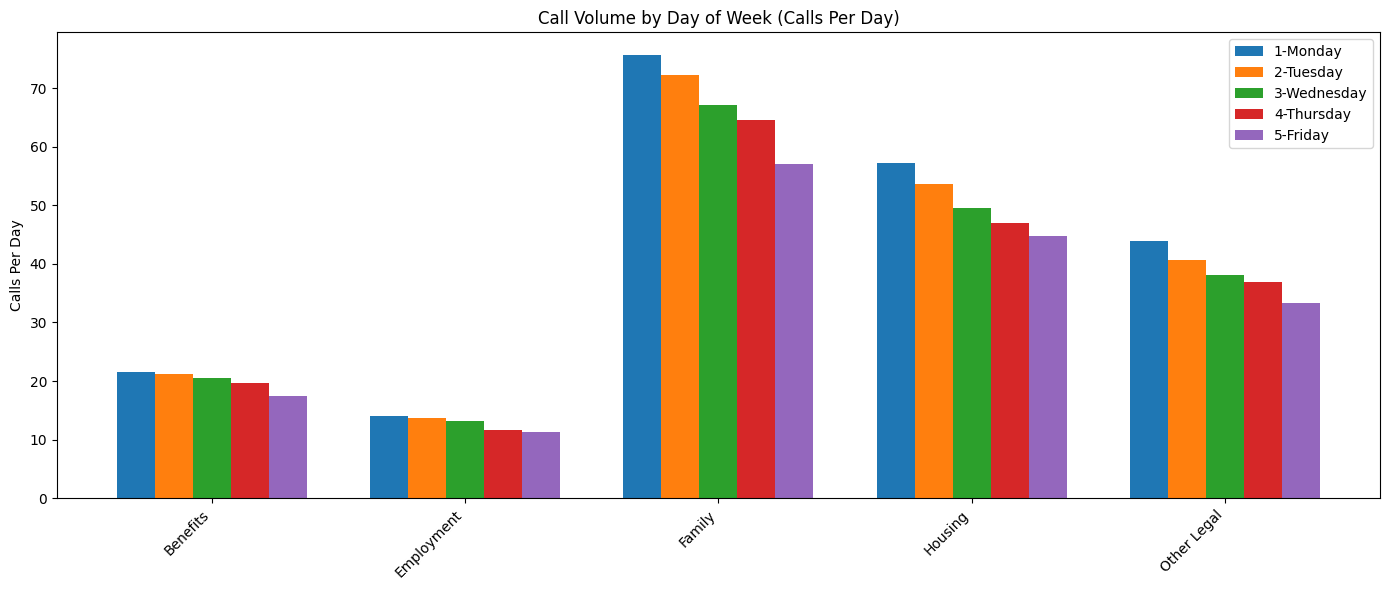

Upload viz3_day_of_week.csv


In [9]:
# CSV 3: Day of Week Analysis (Monday-Friday)

# Add day of week
legal_issues['Day_of_Week'] = legal_issues['Activity Start Timestamp'].dt.dayofweek  

# Filter to weekdays only (Mon-Fri)
legal_issues_weekday = legal_issues[legal_issues['Day_of_Week'] < 5].copy()

# Add day names with number prefixes for proper sorting in Power BI Service
day_name_map = {
    0: '1-Monday',
    1: '2-Tuesday',
    2: '3-Wednesday',
    3: '4-Thursday',
    4: '5-Friday'
}
legal_issues_weekday['Day_Name'] = legal_issues_weekday['Day_of_Week'].map(day_name_map)

# Filter to categories above threshold
top_categories = frequency_summary[frequency_summary['Call_Count'] >= threshold_absolute]['Category'].tolist()
legal_issues_filtered = legal_issues_weekday[legal_issues_weekday['Legal_Category'].isin(top_categories)].copy()

# Group by category and day of week
day_analysis = legal_issues_filtered.groupby(['Legal_Category', 'Day_Name', 'Day_of_Week'])['Contact Session ID'].nunique().reset_index()
day_analysis.columns = ['Legal_Category', 'Day_Name', 'Day_of_Week', 'Call_Count']

# Calculate number of each day type in the dataset
day_counts = legal_issues_filtered.groupby('Day_of_Week')['Activity Start Timestamp'].apply(
    lambda x: x.dt.date.nunique()
).to_dict()

day_analysis['Total_Days'] = day_analysis['Day_of_Week'].map(day_counts)
day_analysis['Calls_Per_Day'] = (day_analysis['Call_Count'] / day_analysis['Total_Days']).round(2)

# Add sort order for days (Monday=1, Friday=5)
day_analysis['Day_Sort'] = day_analysis['Day_of_Week'] + 1

# Select and sort columns
day_analysis = day_analysis[['Legal_Category', 'Day_Name', 'Day_Sort', 
                              'Call_Count', 'Calls_Per_Day']]
day_analysis = day_analysis.sort_values(['Legal_Category', 'Day_Sort'])

day_analysis.to_csv('viz3_day_of_week.csv', index=False)
print("\n✓ Exported: viz3_day_of_week.csv")
print("\nPreview of viz3_day_of_week.csv:")
print(day_analysis.head(20))

# VISUALIZATION 3: Calls Per Day by Day of Week

fig, ax = plt.subplots(figsize=(14, 6))

# Pivot for plotting
day_pivot = day_analysis.pivot(index='Legal_Category', columns='Day_Name', values='Calls_Per_Day').fillna(0)

# Reorder columns by day of week
day_order = ['1-Monday', '2-Tuesday', '3-Wednesday', '4-Thursday', '5-Friday']
day_pivot = day_pivot[[col for col in day_order if col in day_pivot.columns]]

x = range(len(day_pivot))
width = 0.15

for i, day in enumerate(day_pivot.columns):
    ax.bar([pos + width * i for pos in x], day_pivot[day], width, label=day)

ax.set_xticks([pos + width * 2 for pos in x])
ax.set_xticklabels(day_pivot.index, rotation=45, ha='right')
plt.title('Call Volume by Day of Week (Calls Per Day)')
plt.ylabel('Calls Per Day')
plt.legend()
plt.tight_layout()
plt.savefig('viz3_day_of_week.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: viz3_day_of_week.png")
plt.show()

print("Upload viz3_day_of_week.csv")